# Patent Category Analysis

Counts how many patent figure records in the DeepPatent2 dataset relate to:
aircraft, drones/UAVs, helicopters, eVTOLs, spacecraft, ground vehicles, or marine craft.

**Data source:** per-year JSON files, each a list of records with `object`, `object_title`, and `caption` fields.

**Modules:**
- `categories.py` — keyword taxonomy
- `analyzer.py` — load / parse / match / aggregate

In [1]:
import sys
from pathlib import Path

# Absolute path to this notebook's folder — safe regardless of kernel CWD
NOTEBOOK_DIR = Path("/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/src")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# Input: DeepPatent2 per-year JSON files
DATA_DIR = Path("/mnt/storage_11tb/Drive_files_to_syncronize/DeepPatent2")

# Output: all saved files go here
OUTPUT_DIR = NOTEBOOK_DIR / "data"
OUTPUT_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
print(f"Data directory  : {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"JSON files found: {len(list(DATA_DIR.glob('*.json')))}")

Data directory  : /mnt/storage_11tb/Drive_files_to_syncronize/DeepPatent2
Output directory: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data
JSON files found: 15


## Step 1 — Scan data directory

In [2]:
from analyzer import scan_data_dir

json_files = scan_data_dir(DATA_DIR)
print(f"JSON files found: {len(json_files)}")
for f in json_files:
    print(f"  {f.name}")

JSON files found: 15
  design2008.json
  design2009.json
  design2010.json
  design2011.json
  design2012.json
  design2013.json
  design2014.json
  design2015.json
  design2016.json
  design2017.json
  design2018.json
  design2019.json
  design2019part3.json
  design2020.json
  segmentation_2007.json


## Step 2 — Run parsing and categorisation

In [3]:
from analyzer import run_analysis

results = run_analysis(DATA_DIR)

print(f"Files processed : {results['files_found']}")
print(f"Total records   : {results['total_records']:,}")
print(f"Uncategorised   : {results['uncategorized']:,}")

if results['file_errors']:
    print(f"\nFiles with parse errors ({len(results['file_errors'])}):",
          ", ".join(results['file_errors']))

Files processed : 15
Total records   : 2,459,729
Uncategorised   : 2,263,336


## Step 3 — Results table

In [4]:
import pandas as pd
import json

counts = results["category_counts"]
total  = results["total_records"]

df = (
    pd.DataFrame(
        [{"Category": cat, "Matches": n, "% of Total": round(100 * n / total, 3)}
         for cat, n in sorted(counts.items(), key=lambda x: x[1], reverse=True)]
    )
    .reset_index(drop=True)
)

uncategorised_row = pd.DataFrame([{
    "Category": "(Uncategorised)",
    "Matches": results["uncategorized"],
    "% of Total": round(100 * results["uncategorized"] / total, 3)
}])
df = pd.concat([df, uncategorised_row], ignore_index=True)

# Save counts to JSON
counts_out = OUTPUT_DIR / "category_counts.json"
with open(counts_out, "w") as f:
    json.dump(
        {"total_records": total, "category_counts": counts, "uncategorized": results["uncategorized"]},
        f, indent=2
    )
print(f"Counts saved → {counts_out}")

# Save table to CSV
csv_out = OUTPUT_DIR / "category_counts.csv"
df.to_csv(csv_out, index=False)
print(f"Table  saved → {csv_out}")

display(df.style.format({"Matches": "{:,}", "% of Total": "{:.3f}%"}).hide(axis="index"))

Counts saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_counts.json
Table  saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_counts.csv


Category,Matches,% of Total
Landing Gear & Undercarriage,"46,265",1.881%
Payload & Mission Systems,"30,188",1.227%
Power & Energy Systems,"24,738",1.006%
Fuselage & Structure,"23,868",0.970%
Avionics & Control Systems,"22,929",0.932%
Propulsion System,"18,889",0.768%
Air Intake & Exhaust System,"9,911",0.403%
Fixed-Wing Aircraft,"8,088",0.329%
Thermal Management & Cooling,"5,573",0.227%
Control Surfaces & Flight Control,"4,943",0.201%


## Step 3.5 — Export Platform & Subsystem Reports (NEW)

In [5]:
from analyzer import export_csv_reports

print("\n" + "="*70)
print("EXPORTING PLATFORM & SUBSYSTEM REPORTS")
print("="*70 + "\n")

export_csv_reports(results, OUTPUT_DIR)

print("\n✅ Reports saved:")
print(f"   📊 01_platforms_distribution.csv")
print(f"   📊 02_subsystems_distribution.csv")
print(f"   📊 03_platform_subsystem_matrix.csv")
print(f"\n   Location: {OUTPUT_DIR}")


EXPORTING PLATFORM & SUBSYSTEM REPORTS

✓ 01_platforms_distribution.csv
✓ 02_subsystems_distribution.csv
✓ 03_platform_subsystem_matrix.csv

✅ Reports saved:
   📊 01_platforms_distribution.csv
   📊 02_subsystems_distribution.csv
   📊 03_platform_subsystem_matrix.csv

   Location: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data


## Step 4 — Visualisation

/tmp/ipykernel_3628506/649822110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_3628506/649822110.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


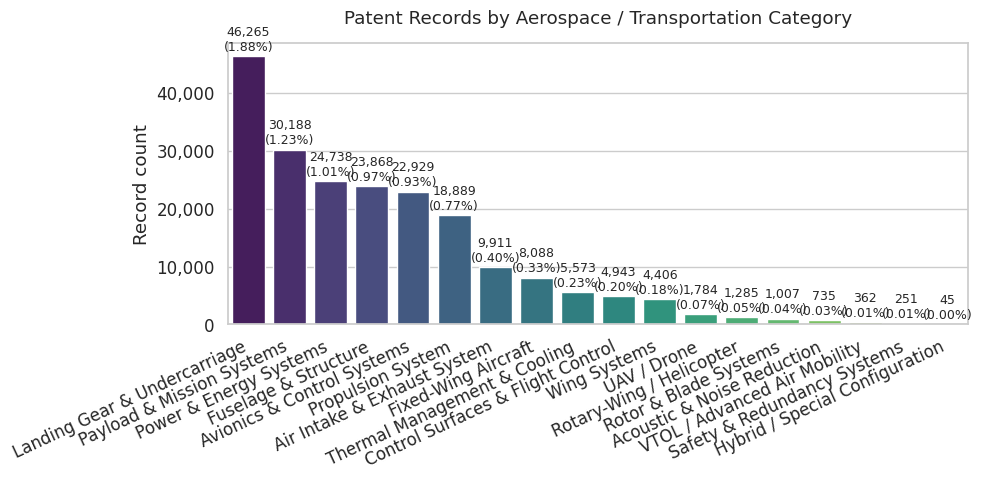

Chart  saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_distribution.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plot_df = df[df["Category"] != "(Uncategorised)"].copy()

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(
    data=plot_df,
    x="Category",
    y="Matches",
    palette="viridis",
    ax=ax,
)

for bar, (_, row) in zip(bars.patches, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(plot_df["Matches"]) * 0.01,
        f"{int(row['Matches']):,}\n({row['% of Total']:.2f}%)",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("Patent Records by Aerospace / Transportation Category", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Record count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

plt.tight_layout()
chart_out = OUTPUT_DIR / "category_distribution.png"
plt.savefig(chart_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart  saved → {chart_out}")

## Step 5 — Inspect sample records (optional)

Preview matching records for any category to spot false positives or tune keywords.

In [7]:
INSPECT_CATEGORY = "Aircraft (Fixed-Wing)"   # ← change as needed
N_SAMPLES = 10

sample_records = results["category_records"].get(INSPECT_CATEGORY, [])[:N_SAMPLES]

if not sample_records:
    print(f"No records found for '{INSPECT_CATEGORY}'.")
else:
    sample_df = pd.DataFrame(sample_records)[
        [c for c in ("patentID", "object", "object_title", "caption") if c in sample_records[0]]
    ]
    pd.set_option("display.max_colwidth", 120)
    display(sample_df)

No records found for 'Aircraft (Fixed-Wing)'.


## Step 6 — Compare with External Excel Dataset

Cross-reference the categorized patents against an external validation dataset (PatSeer Gold Standard).

In [8]:
from excel_comparator import (
    load_excel_patents,
    extract_patents_from_analysis,
    compare_patents,
    print_comparison_summary,
    save_overlap_to_csv,
)

# ──────────────────────────────────────────────────────────────────────────
# CONFIGURE: Excel file path
EXCEL_PATH = Path("/mnt/storage_11tb/Drive_files_to_syncronize/2 - Patente & Validation/3 -Raw_Patent_Exports_PatSeer_&Gold_Standard/1627__dataset_26_05_26.xlsx")
# ──────────────────────────────────────────────────────────────────────────

print(f"Loading Excel file...")
excel_df = load_excel_patents(EXCEL_PATH)
print(f"Loaded {len(excel_df):,} records from Excel")
print(f"Columns: {list(excel_df.columns)}")

# Extract patent IDs from our analysis
json_patents = extract_patents_from_analysis(results)
print(f"\nExtracted {len(json_patents):,} patent IDs from analysis")

# Run the comparison
comparison = compare_patents(
    json_patents,
    excel_df,
    categorization_column="Tech Domain",  # ← Change to other columns like "Industry", "Tech Sub Domain"
)

# Print summary
print_comparison_summary(comparison)

Loading Excel file...


/home/vasco/anaconda3/envs/doclayout_yolo/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 1,627 records from Excel
Columns: ['Record Number', 'Tech Domain', 'Tech Sub Domain', 'Industry', 'Title', 'CPC', 'Record Number (Normalized)']

Extracted 30,173 patent IDs from analysis
PATENT COMPARISON SUMMARY (with normalized ID matching)
Total patents in JSON analysis      : 30,173
Total patents in Excel file         : 1,627
Overlapping patents found           : 0
Overlap percentage (vs Excel)       : 0.00%

Match method: normalized core numbers
Normalized core IDs that matched    : 0

Categorization by 'Tech Domain':
----------------------------------------------------------------------
  (No categorization data available)


### Overlapping Patents by Category

In [9]:
# Create a bar chart of overlapping patents by category
overlap_counts = comparison["category_breakdown"]
if overlap_counts:
    overlap_df = pd.DataFrame(
        [{"Category": cat, "Count": n} for cat, n in sorted(overlap_counts.items(), key=lambda x: x[1], reverse=True)]
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = sns.barplot(
        data=overlap_df,
        x="Category",
        y="Count",
        palette="rocket",
        ax=ax,
    )

    # Annotate bars
    for bar, (_, row) in zip(bars.patches, overlap_df.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(overlap_df["Count"]) * 0.01,
            f"{int(row['Count']):,}",
            ha="center", va="bottom", fontsize=10, weight="bold"
        )

    ax.set_title(
        f"Overlapping Patents by {comparison['categorization_column']} "
        f"({comparison['overlap_count']:,} matches)",
        pad=14,
        fontsize=12,
    )
    ax.set_xlabel(comparison["categorization_column"])
    ax.set_ylabel("Number of Patents")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

    plt.tight_layout()
    overlap_chart = OUTPUT_DIR / "overlap_by_category.png"
    plt.savefig(overlap_chart, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Overlap chart saved → {overlap_chart}")
else:
    print("No category breakdown available.")

# Save overlapping patents to CSV
overlap_csv = OUTPUT_DIR / "overlapping_patents.csv"
save_overlap_to_csv(comparison, overlap_csv)

No category breakdown available.
Overlap data saved to: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/overlapping_patents.csv


### Detailed Inspection of Overlaps (optional)

Inspect specific patents that appear in both datasets.

In [10]:
# Inspect a sample of overlapping patents
N_INSPECT = 15
sample_overlap = comparison["excel_records_overlap"].head(N_INSPECT)[
    ["Record Number", "Tech Domain", "Tech Sub Domain", "Industry", "Title"]
]

print(f"Sample of {N_INSPECT} overlapping patents (from Excel):\n")
pd.set_option("display.max_colwidth", 100)
display(sample_overlap)

# Show summary stats per category
print(f"\nBreakdown by {comparison['categorization_column']}:")
breakdown_df = pd.DataFrame([
    {
        "Category": cat,
        "Count": count,
        "% of Overlap": round(100 * count / comparison["overlap_count"], 2)
    }
    for cat, count in sorted(
        comparison["category_breakdown"].items(),
        key=lambda x: x[1],
        reverse=True
    )
])
display(breakdown_df)

Sample of 15 overlapping patents (from Excel):



,Record Number,Tech Domain,Tech Sub Domain,Industry,Title



Breakdown by Tech Domain:


""
